# Notebook 02 - Coverage & Gap Analysis

**Goal:** assign every external (AG News) and internal (CNN/DailyMail) document to the topics
discovered in notebook 01 using one shared similarity rule, then rank content gaps where external
demand outstrips internal coverage.

## Setup

In [1]:
# Setup: folders, seed, device and config. Same setup as notebook 01 so the results stay comparable.
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")   # prevents Apple Silicon crash
os.environ.setdefault("OMP_NUM_THREADS", "1")
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.environ["HF_HOME"] = str(ROOT / "hf_cache")           # models/datasets downloaded once, stored here
DATA_DIR, CACHE_DIR, OUTPUTS_DIR, EVAL_DIR = (ROOT / d for d in ("data", "cache", "outputs", "eval"))
for d in (DATA_DIR, CACHE_DIR, OUTPUTS_DIR, EVAL_DIR): d.mkdir(exist_ok=True)
from dotenv import load_dotenv; load_dotenv(ROOT / ".env")  # OPENAI_API_KEY

import random
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
rng = random.Random(SEED)

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"Using device: {DEVICE}")

CONFIG = {
    "seed": SEED,
    "device": DEVICE,
    "emb_model": "sentence-transformers/all-MiniLM-L6-v2",
    "emb_batch_size": 64,
    "tau_start": 0.40,
}
CONFIG

Using device: mps


{'seed': 42,
 'device': 'mps',
 'emb_model': 'sentence-transformers/all-MiniLM-L6-v2',
 'emb_batch_size': 64,
 'tau_start': 0.4}

Load notebook 01's outputs: topics, centroids, AG News embeddings, the AG tech mask and the group embeddings.

In [2]:
# Load what notebook 01 saved: topics, centroids, AG News embeddings, tech mask and group embeddings.
# The asserts check that row counts match. If they don't, topic ids would point to the wrong centroid.
topics_csv = pd.read_csv(OUTPUTS_DIR / "topics.csv")
assert (topics_csv["topic_id"].values == np.sort(topics_csv["topic_id"].values)).all(), \
    "topics.csv must be sorted by ascending topic_id to align with topic_centroids.npy rows"

centroid_matrix = np.load(CACHE_DIR / "topic_centroids.npy")
assert centroid_matrix.shape[0] == len(topics_csv), "centroid rows must match topics.csv rows"

topic_ids = topics_csv["topic_id"].to_numpy()
topic_name_map = dict(zip(topics_csv.topic_id, topics_csv.topic_name))
print(f"Loaded {len(topic_ids)} topics and centroids of dim {centroid_matrix.shape[1]}")

ag_df = pd.read_parquet(DATA_DIR / "ag_clean.parquet")
ag_embeddings = np.load(CACHE_DIR / "ag_emb.npy")
assert len(ag_df) == len(ag_embeddings), "ag_clean.parquet and ag_emb.npy row counts must match"
print(f"Loaded {len(ag_df):,} external (AG News) docs with embeddings")
ag_is_tech = np.load(CACHE_DIR / "ag_tech_mask.npy")
group_emb = np.load(CACHE_DIR / "group_emb.npy")
assert len(ag_is_tech) == len(ag_embeddings), "ag_tech_mask.npy and ag_emb.npy row counts must match"
print(f"Loaded tech mask ({int(ag_is_tech.sum()):,} tech rows) and group embeddings {group_emb.shape}")

Loaded 32 topics and centroids of dim 384
Loaded 63,396 external (AG News) docs with embeddings
Loaded tech mask (31,007 tech rows) and group embeddings (4, 384)


## 6.1 Load internal documents & embed highlights (shared assignment rule)

Kept as an Arrow-backed `Dataset` (memory-mapped) with only the columns needed here - `id` and
`highlights` - never materializing the full 300k-article text in memory.

In [3]:
# Load the CNN/DailyMail file. We only keep id and highlights, because highlights are short and the full article is not needed.
# The dataset is memory mapped, so 300k rows do not fill up RAM.
from datasets import Dataset as HFDataset

cnn_ds = HFDataset.from_parquet(str(DATA_DIR / "cnn_clean.parquet"))
cnn_ds = cnn_ds.select_columns(["id", "highlights"])
print(f"Loaded {len(cnn_ds):,} internal documents")

cnn_ids = np.array(cnn_ds["id"])
cnn_highlights = cnn_ds["highlights"]

Generating train split: 0 examples [00:00, ? examples/s]

Loaded 306,913 internal documents


In [4]:
# Embed the CNN highlights with the same model used for AG News.
# This takes about 15 minutes, so the result is saved in cache/ and loaded next time if the ids match.
# Vectors are normalized, so dot product = cosine similarity.
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer(CONFIG["emb_model"], device=DEVICE)

cnn_hl_emb_path = CACHE_DIR / "cnn_hl_emb.npy"
cnn_hl_ids_path = CACHE_DIR / "cnn_hl_ids.npy"

if cnn_hl_emb_path.exists() and cnn_hl_ids_path.exists():
    cached_ids = np.load(cnn_hl_ids_path, allow_pickle=True)
    if len(cached_ids) == len(cnn_ids) and (cached_ids == cnn_ids).all():
        cnn_hl_embeddings = np.load(cnn_hl_emb_path)
        print(f"Loaded cached internal embeddings: {cnn_hl_embeddings.shape}")
    else:
        cnn_hl_embeddings = None
else:
    cnn_hl_embeddings = None

if cnn_hl_embeddings is None:
    t0 = time.time()
    cnn_hl_embeddings = embed_model.encode(
        cnn_highlights, batch_size=CONFIG["emb_batch_size"], show_progress_bar=True,
        normalize_embeddings=True,
    )
    print(f"Embedded {len(cnn_highlights):,} internal highlights in {time.time() - t0:.1f}s")
    np.save(cnn_hl_emb_path, cnn_hl_embeddings)
    np.save(cnn_hl_ids_path, cnn_ids)

cnn_hl_embeddings.shape

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/4796 [00:00<?, ?it/s]

Embedded 306,913 internal highlights in 905.7s


(306913, 384)

### Rule

Cosine similarity to every topic centroid (dot product, since both sides are L2-normalized);
assign the best-matching topic if its similarity is at least `TAU`, else `unmatched` (sentinel
`-1`). The same function is applied to external and internal embeddings so their shares stay
comparable.

In [5]:
# Assignment rule: compare a doc with every topic centroid and take the best one.
# If the best score is below tau, the doc is unmatched (-1).
# The same function is used for AG and CNN, so the shares can be compared fairly.
def assign_topics(embeddings, centroids, tau):
    sims = embeddings @ centroids.T
    best_pos = sims.argmax(axis=1)
    best_sim = sims[np.arange(len(embeddings)), best_pos]
    assigned = np.where(best_sim >= tau, topic_ids[best_pos], -1)
    return assigned, best_sim

## Internal tech filter

Same rule as notebook 01: each internal highlight goes to the closest group description; only `tech` rows are used.

In [6]:
# Tech filter for CNN, same idea as notebook 01: each highlight goes to its closest group description, and we keep only the tech ones.
# We print counts and 25 random rows to check by eye. The filter is a bit loose (some sport/celeb rows get in), see the assumptions below.
GROUP_NAMES = ["tech", "business", "science", "general"]   # same order as GROUPS in notebook 01
cnn_group = (cnn_hl_embeddings @ group_emb.T).argmax(axis=1)
cnn_is_tech = cnn_group == 0
print(pd.Series(np.array(GROUP_NAMES)[cnn_group]).value_counts())

print("--- 25 random tech highlights ---")
for i in rng.sample(list(np.where(cnn_is_tech)[0]), min(25, int(cnn_is_tech.sum()))):
    print("-", cnn_highlights[i][:200])

general     133871
science      93782
tech         50873
business     28387
Name: count, dtype: int64
--- 25 random tech highlights ---
- Midfielder Darren Fletcher signed for West Brom from Manchester United . He penned a two-and-a-half year deal at the club and moved on a free . Fletcher joins up with former United team-mate, goalkeep
- Bitcoin's executive director Jon Matonis tells CNN people should only invest what they can lose . His comments come after the meltdown of Mt Gox, one of the biggest Bitcoin exchanges . Matonis says Bi
- Top seed Caroline Wozniacki win the inaugural WTA Danish Open title on Sunday . The local favorite defeats Czech Klara Zakapolova 6-2 7-6 in the final in Copenhagen . The 20-year-old is ranked third i
- Collection of 410 illustrations span the range of work of Heath Robinson . Includes many of his well-known First and Second World War cartoons . Pictures were put up for sale following death of owner 
- The FBI has obtained a warrant for the arrest of J

In [12]:
# Apply the assignment rule to the tech rows of AG and CNN.
# TAU = 0.45 was picked after trying 0.40, 0.45 and 0.50.
# 0.40 let in too many wrong matches, 0.50 left too few internal docs (about 2.4k).
TAU = 0.45

ext_topic, ext_sim = assign_topics(ag_embeddings[ag_is_tech], centroid_matrix, TAU)
int_topic, int_sim = assign_topics(cnn_hl_embeddings[cnn_is_tech], centroid_matrix, TAU)
cnn_ids_tech = cnn_ids[cnn_is_tech]
cnn_highlights_tech = [h for h, t in zip(cnn_highlights, cnn_is_tech) if t]

ext_matched = ext_topic != -1
int_matched = int_topic != -1
print(f"External matched: {ext_matched.sum():,}/{len(ext_topic):,} ({100 * ext_matched.mean():.1f}%)")
print(f"Internal matched: {int_matched.sum():,}/{len(int_topic):,} ({100 * int_matched.mean():.1f}%)")

print("--- 10 random internal matches ---")
for i in rng.sample(list(np.where(int_matched)[0]), min(10, int(int_matched.sum()))):
    print(f"  sim={int_sim[i]:.3f} | topic={topic_name_map[int_topic[i]]!r} | {cnn_highlights_tech[i][:140]!r}")

External matched: 22,547/31,007 (72.7%)
Internal matched: 4,562/50,873 (9.0%)
--- 10 random internal matches ---
  sim=0.501 | topic='Cybersecurity Threats and Responses' | 'Malware can impersonate other apps in order to gain access to secure areas of your phone . Vulnerability dates back to the January 2010 rele'
  sim=0.470 | topic='Cybersecurity Threats and Responses' | 'NEW: NSA director repeats his statement that surveillance network thwarted 54 terror plots . Sen. Leahy: Classified details show phone recor'
  sim=0.496 | topic='Media Center PC Innovations' | "Phone rumoured to show images that 'float above the screen like holograms' Jeff Bezos set to unveil event at a launch in Seattle tomorrow . "
  sim=0.534 | topic='Cybersecurity Threats and Responses' | 'FBI agents claim gang hacked a top-secret US Army helicopter simulator . The software is used to train pilots fly the Apache AH-64D gunship '
  sim=0.512 | topic='Apple iTunes Music Store Updates' | "John Sculley said Apple m

## 6.3 Metrics per topic

In [14]:
# Numbers per topic: doc count, share of matched docs, and coverage ratio (internal share / external share).
# Low if ratio < 0.5, Medium if 0.5 to 1.5, High if above 1.5.
# Gap = external share - internal share. Bigger gap = more missing internal content. Rank is sorted by gap.
ext_counts = pd.Series(ext_topic[ext_matched]).value_counts()
int_counts = pd.Series(int_topic[int_matched]).value_counts()

gap_df = topics_csv[["topic_id", "topic_name"]].copy()
gap_df["ext_count"] = gap_df["topic_id"].map(ext_counts).fillna(0).astype(int)
gap_df["int_count"] = gap_df["topic_id"].map(int_counts).fillna(0).astype(int)
gap_df["ext_share"] = gap_df["ext_count"] / gap_df["ext_count"].sum()
gap_df["int_share"] = gap_df["int_count"] / gap_df["int_count"].sum()
gap_df["coverage_ratio"] = gap_df["int_share"] / gap_df["ext_share"]

def coverage_level(row):
    if row["coverage_ratio"] < 0.5:
        return "Low"
    if row["coverage_ratio"] <= 1.5:
        return "Medium"
    return "High"

gap_df["coverage_level"] = gap_df.apply(coverage_level, axis=1)
gap_df["gap"] = gap_df["ext_share"] - gap_df["int_share"]
gap_df = gap_df.sort_values("gap", ascending=False).reset_index(drop=True)
gap_df["rank"] = np.arange(1, len(gap_df) + 1)
gap_df

,topic_id,topic_name,ext_count,int_count,ext_share,int_share,coverage_ratio,coverage_level,gap,rank
0,7,Intel and AMD Processor Developments,1141,26,0.050605,0.005699,0.112621,Low,0.044906,1
1,6,Oracle Corp. Takeover Bid,882,1,0.039118,0.000219,0.005604,Low,0.038899,2
2,22,Oracle Enterprise Software Innovations,796,7,0.035304,0.001534,0.043463,Low,0.033770,3
3,26,Microsoft Windows Server Release 2006,1031,64,0.045727,0.014029,0.306800,Low,0.031698,4
4,12,Windows XP Security Updates,671,6,0.029760,0.001315,0.044194,Low,0.028445,5
5,1,Stock Market Movements,1564,189,0.069366,0.041429,0.597253,Medium,0.027937,6
6,23,IBM PC Business Sale,704,26,0.031224,0.005699,0.182530,Low,0.025524,7
7,19,Linux and Open Source Developments,603,6,0.026744,0.001315,0.049178,Low,0.025429,8
8,18,HP Server Innovations,598,16,0.026522,0.003507,0.132237,Low,0.023015,9
9,16,Sun Microsystems and Solaris 10,438,5,0.019426,0.001096,0.056420,Low,0.018330,10


## 6.5 Outputs

In [15]:
# Save the ranking to outputs/gap_ranking.csv and show the top 10.
gap_out = gap_df[[
    "topic_id", "topic_name", "ext_count", "int_count", "ext_share", "int_share",
    "coverage_ratio", "coverage_level", "gap", "rank",
]]
gap_out.to_csv(OUTPUTS_DIR / "gap_ranking.csv", index=False)
print(f"Saved {OUTPUTS_DIR / 'gap_ranking.csv'}")
gap_out.head(10)

Saved /Users/shubhamyadav/Desktop/topic_modelling/case-study/outputs/gap_ranking.csv


,topic_id,topic_name,ext_count,int_count,ext_share,int_share,coverage_ratio,coverage_level,gap,rank
0,7,Intel and AMD Processor Developments,1141,26,0.050605,0.005699,0.112621,Low,0.044906,1
1,6,Oracle Corp. Takeover Bid,882,1,0.039118,0.000219,0.005604,Low,0.038899,2
2,22,Oracle Enterprise Software Innovations,796,7,0.035304,0.001534,0.043463,Low,0.033770,3
3,26,Microsoft Windows Server Release 2006,1031,64,0.045727,0.014029,0.306800,Low,0.031698,4
4,12,Windows XP Security Updates,671,6,0.029760,0.001315,0.044194,Low,0.028445,5
5,1,Stock Market Movements,1564,189,0.069366,0.041429,0.597253,Medium,0.027937,6
6,23,IBM PC Business Sale,704,26,0.031224,0.005699,0.182530,Low,0.025524,7
7,19,Linux and Open Source Developments,603,6,0.026744,0.001315,0.049178,Low,0.025429,8
8,18,HP Server Innovations,598,16,0.026522,0.003507,0.132237,Low,0.023015,9
9,16,Sun Microsystems and Solaris 10,438,5,0.019426,0.001096,0.056420,Low,0.018330,10


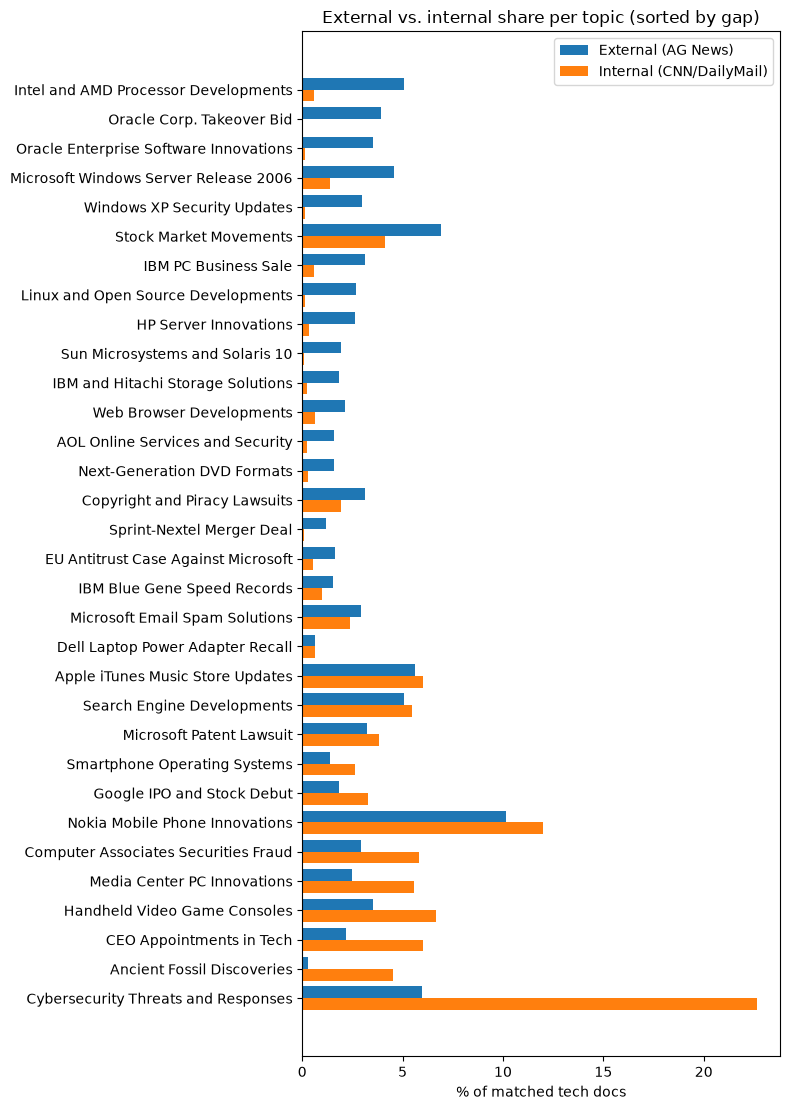

In [16]:
# Bar chart of external vs internal share per topic, sorted by gap. Saved as a png for the slides.
plot_df = gap_out.sort_values("gap")   # largest gap ends up at the top
y = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(plot_df))))
ax.barh(y + 0.2, plot_df["ext_share"] * 100, height=0.4, label="External (AG News)")
ax.barh(y - 0.2, plot_df["int_share"] * 100, height=0.4, label="Internal (CNN/DailyMail)")
ax.set_yticks(y)
ax.set_yticklabels(plot_df["topic_name"])
ax.set_xlabel("% of matched tech docs")
ax.set_title("External vs. internal share per topic (sorted by gap)")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "gap_chart.png", dpi=150)
plt.show()

### Gap insights

Numbers below are at TAU = 0.45.

- **Biggest gaps:** Intel and AMD Processors, Oracle Takeover, Oracle Enterprise Software, Windows Server and Windows XP. External share is 3% to 5% for each, internal share is close to 0%.
- Most of the top 10 are enterprise and hardware vendor topics (Oracle, IBM, HP, Sun, Linux). We have very little internal content on them.
- Stock Market Movements ranks #6 but is non-tech leakage from the filter (see notebook 01), so it's excluded from recommendations, like Ancient Fossil Discoveries.
- **Balanced:** iTunes, Search Engine and Nokia Mobile are close to 1, so internal and external are about the same.
- **Over covered:** Cybersecurity (6% external vs 23% internal), CEO Appointments, Handheld Gaming and Media Center PC. Adding more content here will not help much.
- **Careful:** part of this gap is only because of time. AG News is from 2004-2005 and CNN/DailyMail is from later years, so old topics like Windows XP or Solaris will always look uncovered. Use this ranking as a list of topics to look at, not as a final answer.

### Notes and assumptions

- AG News = external demand, CNN/DailyMail = internal content.
- We use only tech rows on both sides. The tech filter picks the closest of 4 group descriptions. It works well for AG News but is loose for CNN, so some sport and celebrity stories get in. Most of them are dropped later by TAU.
- TAU = 0.45 is a middle choice. Only about 9% of internal tech rows match a topic, and shares are calculated on matched docs only.
- Topics come from AG News (old news), so the gap is partly a time difference and not only missing content.
- "Ancient Fossil Discoveries" is a science topic that slipped into the topic list. It should be ignored when we make recommendations.
- Cybersecurity is a very broad topic and also picks up surveillance and crime news, so its internal share is higher than it should be.
- Topics with very few internal docs (for example Oracle Takeover has 1) have unreliable ratios. Only the direction is useful.
- The goal here is the method, not perfect accuracy.

In [ ]:
# Save the matched internal docs with their topic and similarity.
# The RAG notebook will use this file as its document source.
cnn_matched = pd.DataFrame({
    "id": cnn_ids_tech[int_matched],
    "topic_id": int_topic[int_matched],
    "similarity": int_sim[int_matched],
})
cnn_matched["topic_name"] = cnn_matched["topic_id"].map(topic_name_map)
cnn_matched = cnn_matched[["id", "topic_id", "topic_name", "similarity"]]
cnn_matched.to_parquet(DATA_DIR / "cnn_matched.parquet", index=False)
print(f"Saved {len(cnn_matched):,} matched internal docs -> data/cnn_matched.parquet")

Saved 4,562 matched internal docs -> data/cnn_matched.parquet (RAG corpus source)
